In [ ]:
#EXTRAINDO OS DADOS

In [1]:
import pandas as pd
import emoji

def extrair_emojis_unicos(texto):
    """
    Retorna um conjunto de emojis únicos presentes no texto.
    Cada emoji conta no máximo uma vez por tweet.
    Emojis compostos são tratados corretamente.
    """
    if pd.isna(texto):
        return set()
    return set(emoji.distinct_emoji_list(texto))

In [2]:
df_instagram  = pd.read_csv("../../00-source/HateBR-main/dataset/HateBR.csv")
df_instagram.head()

,id,comentario,anotator1,anotator2,anotator3,label_final,links_post,account_post
0,1,Mais um lixo,1,1,1,1,https://www.instagram.com/p/B2uThqdH9xI/,Carla Zambelli
1,2,Essa nao tem vergonha na cara!!,1,1,1,1,https://www.instagram.com/p/B2uThqdH9xI/,Carla Zambelli
2,3,Essa mulher é doente.pilantra!,1,1,1,1,https://www.instagram.com/p/B2uThqdH9xI/,Carla Zambelli
3,4,Comunista safada...,1,1,1,1,https://www.instagram.com/p/B2uThqdH9xI/,Carla Zambelli
4,5,Vagabunda. Comunista. Mentirosa. O povo chilen...,1,1,1,1,https://www.instagram.com/p/B2uThqdH9xI/,Carla Zambelli


In [3]:
df_youtube_train = pd.read_parquet("../../00-source/olid-br/data/train-00000-of-00001-0d8933b80051ca0e.parquet")
df_youtube_test  = pd.read_parquet("../../00-source/olid-br/data/test-00000-of-00001-914dbee7561d2266.parquet")

df_youtube = pd.concat(
    [df_youtube_train, df_youtube_test],
    ignore_index=True
)

df_youtube.shape

(6952, 17)

In [4]:
df_twitter = pd.read_csv("../../00-source/ToLD-Br-main/ToLD-BR.csv")
df_twitter.head()

,text,homophobia,obscene,insult,racism,misogyny,xenophobia
0,Meu nivel de amizade com isis é ela ter meu in...,0.0,0.0,2.0,0.0,0.0,0.0
1,"rt @user @user o cara adultera dados, que fora...",0.0,0.0,1.0,0.0,0.0,0.0
2,@user @user @user o cara só é simplesmente o m...,0.0,2.0,1.0,0.0,0.0,0.0
3,eu to chorando vei vsf e eu nem staneio izone ...,0.0,1.0,0.0,0.0,0.0,0.0
4,Eleitor do Bolsonaro é tão ignorante q não per...,0.0,1.0,2.0,0.0,0.0,0.0


In [5]:
#PADRONIZANDO AS INSTÂNCIAS

In [6]:
df_instagram["emojis"] = df_instagram["comentario"].apply(extrair_emojis_unicos)

df_youtube["emojis"] = df_youtube["text"].apply(extrair_emojis_unicos)

df_twitter["emojis"] = df_twitter["text"].apply(extrair_emojis_unicos)

In [7]:
#ADEQUANDO O YOUTUBE

In [8]:
df_youtube["label_final"] = (
    df_youtube["is_offensive"]
    .str.strip()
    .str.upper()
    .map({
        "OFF": 1,
        "NOT": 0
    })
)

In [9]:
df_youtube["label_final"].value_counts(dropna=False)

label_final
1    5936
0    1016
Name: count, dtype: int64

In [11]:
#ADEQUANDO O TWITTER

In [12]:
colunas_odio_twitter = [
    "homophobia", "obscene", "insult",
    "racism", "misogyny", "xenophobia"
]

df_twitter["label_final"] = (
    df_twitter[colunas_odio_twitter]
    .gt(0)        # qualquer valor > 0 vira True
    .any(axis=1)  # verifica se existe pelo menos um True
    .astype(int)  # converte para 0/1
)

In [13]:
for col in colunas_odio_twitter:
    print(col)
    print(df_twitter[col].value_counts(dropna=False))
    print("-----")

homophobia
homophobia
0.0    20656
1.0      168
2.0      102
3.0       74
Name: count, dtype: int64
-----
obscene
obscene
0.0    14348
1.0     4249
2.0     1791
3.0      612
Name: count, dtype: int64
-----
insult
insult
0.0    16615
1.0     2516
2.0     1352
3.0      517
Name: count, dtype: int64
-----
racism
racism
0.0    20862
1.0      105
2.0       27
3.0        6
Name: count, dtype: int64
-----
misogyny
misogyny
0.0    20537
1.0      330
2.0      104
3.0       29
Name: count, dtype: int64
-----
xenophobia
xenophobia
0.0    20849
1.0      109
2.0       27
3.0       15
Name: count, dtype: int64
-----


In [14]:
df_twitter["label_final"].value_counts(dropna=False)

label_final
0    11745
1     9255
Name: count, dtype: int64

In [15]:
def resumo_plataforma(df, nome):
    
    total_mensagens = df.shape[0]
    
    total_odio = df[df["label_final"] == 1].shape[0]
    total_nao_odio = df[df["label_final"] == 0].shape[0]
    
    mensagens_com_emoji = df[df["emojis"].apply(len) > 0].shape[0]
    
    total_emojis_ocorrencias = df["emojis"].apply(len).sum()
    
    emojis_unicos = set(e for conjunto in df["emojis"] for e in conjunto)
    total_emojis_unicos = len(emojis_unicos)
    
    percentual_com_emoji = (mensagens_com_emoji / total_mensagens) * 100
    
    return {
        "Plataforma": nome,
        "Total de mensagens": total_mensagens,
        "Mensagens de ódio": total_odio,
        "Mensagens não ódio": total_nao_odio,
        "Mensagens com emoji": mensagens_com_emoji,
        "% mensagens com emoji": round(percentual_com_emoji, 2),
        "Total de ocorrências de emojis": total_emojis_ocorrencias,
        "Emojis únicos": total_emojis_unicos
    }

In [16]:
resumo_geral = pd.DataFrame([
    resumo_plataforma(df_instagram, "Instagram"),
    resumo_plataforma(df_youtube, "YouTube"),
    resumo_plataforma(df_twitter, "Twitter/X")
])

resumo_geral

,Plataforma,Total de mensagens,Mensagens de ódio,Mensagens não ódio,Mensagens com emoji,% mensagens com emoji,Total de ocorrências de emojis,Emojis únicos
0,Instagram,7000,3500,3500,2002,28.60,3070,319
1,YouTube,6952,5936,1016,661,9.51,949,270
2,Twitter/X,21000,9255,11745,2266,10.79,3591,527


In [27]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "Times", "DejaVu Serif"]

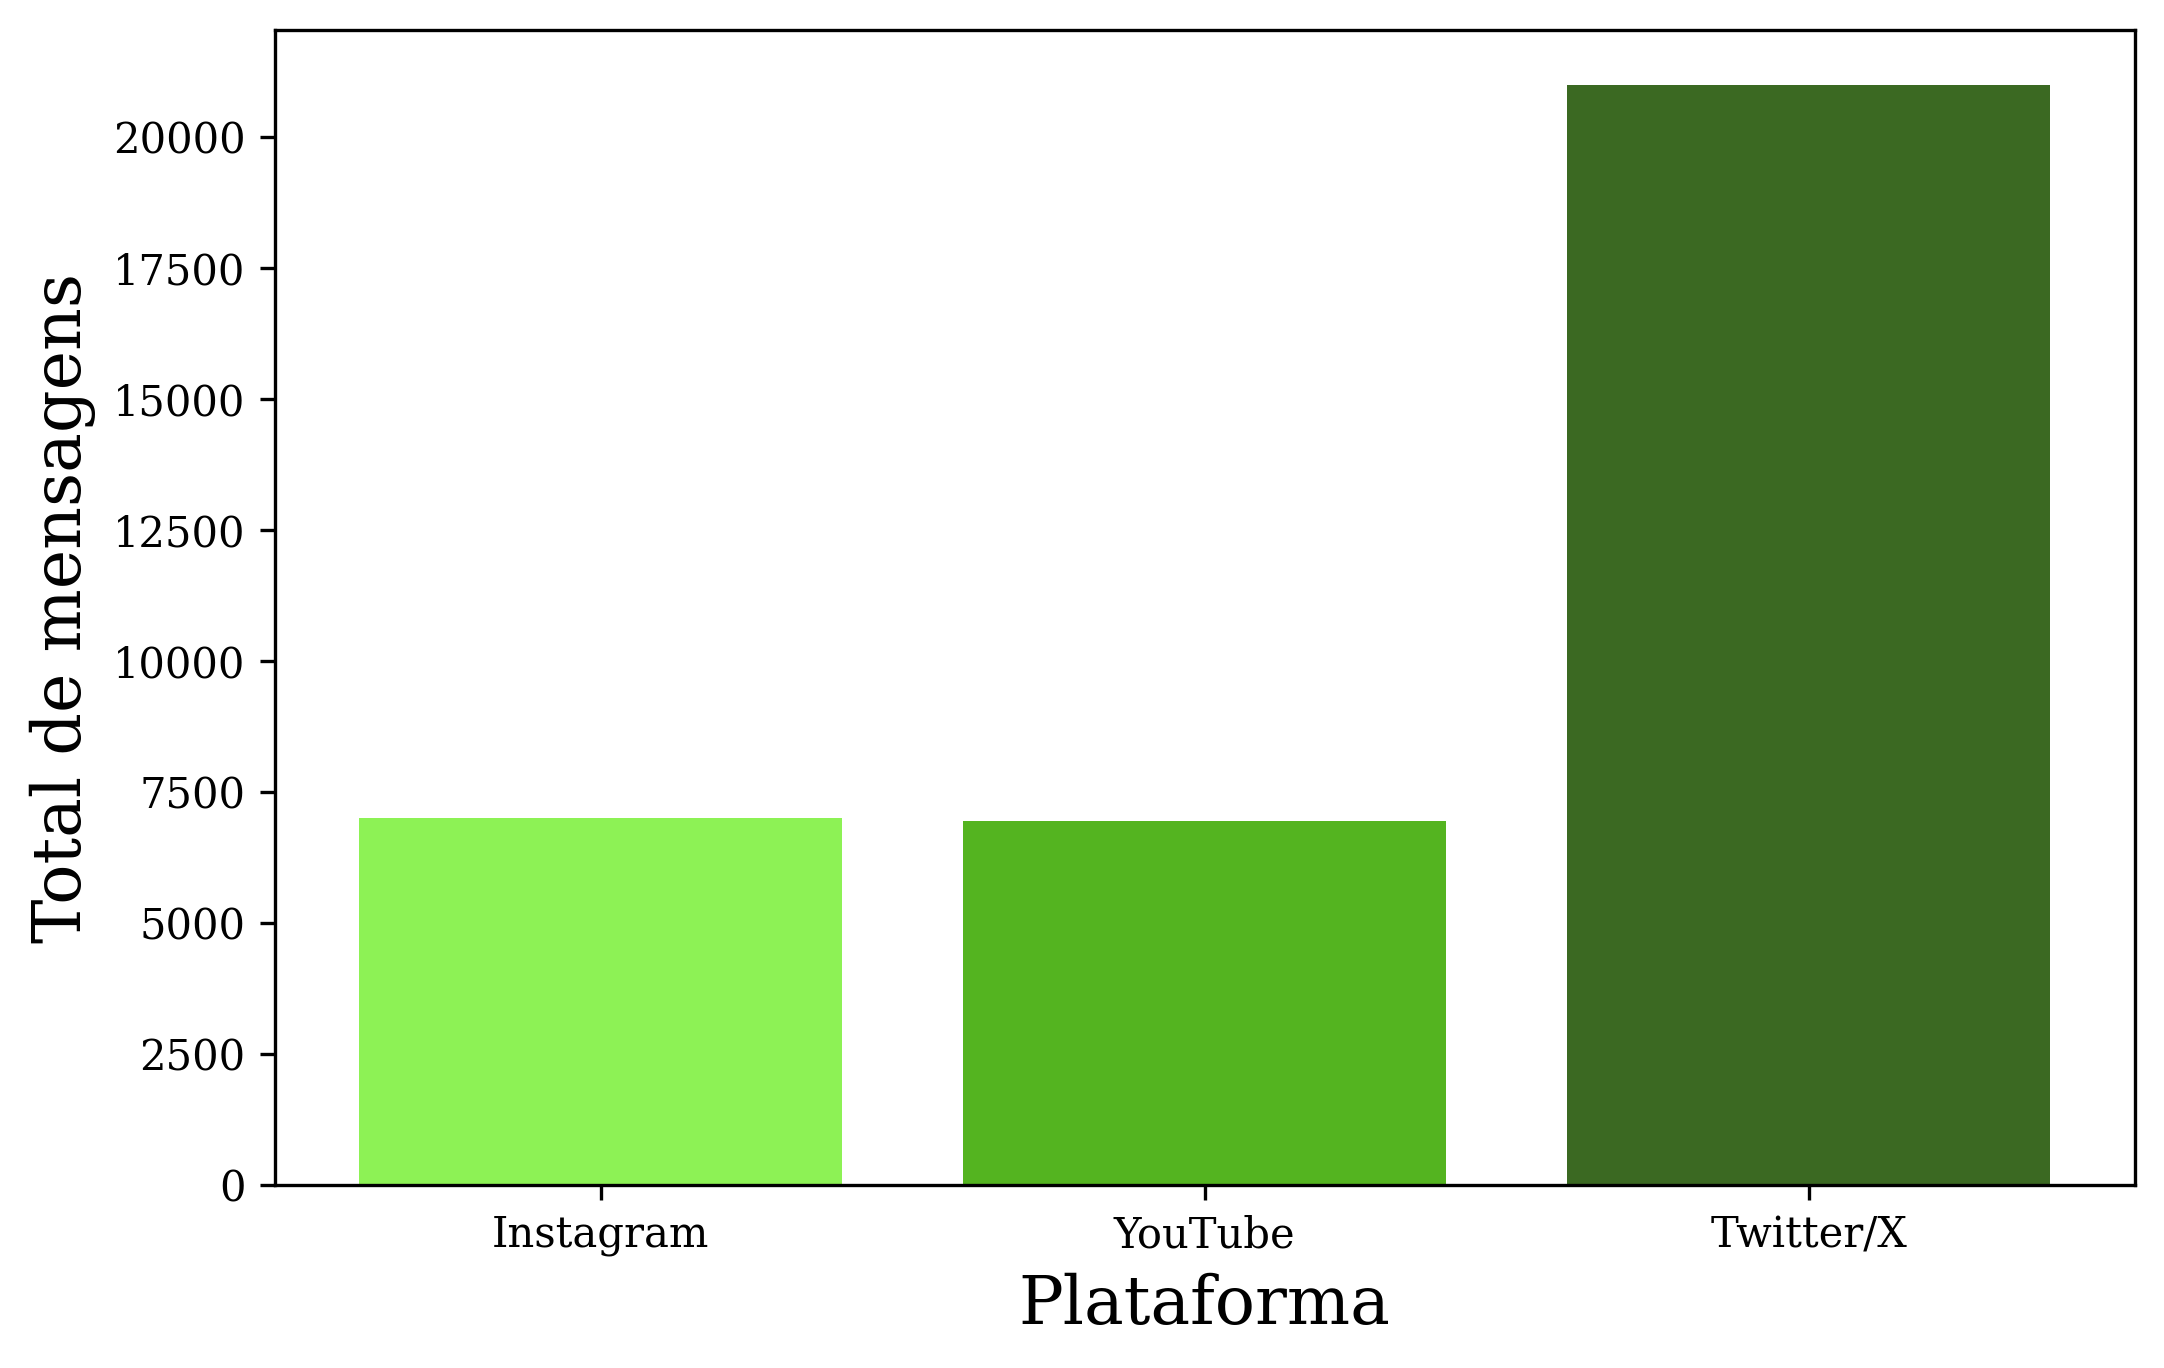

In [28]:
import matplotlib.pyplot as plt

# Definindo cores na mesma ordem das plataformas
cores = ["#8DF255", "#54B420", "#3B6922"] 
# Instagram = 8DF255
# YouTube = 54B420
# Twitter/X = 3B6922

plt.figure(figsize=(8,5), dpi=300)

plt.bar(resumo_geral["Plataforma"],
        resumo_geral["Total de mensagens"],
        color=cores)

plt.xlabel("Plataforma", fontsize=16)
plt.ylabel("Total de mensagens", fontsize=16)

plt.show()

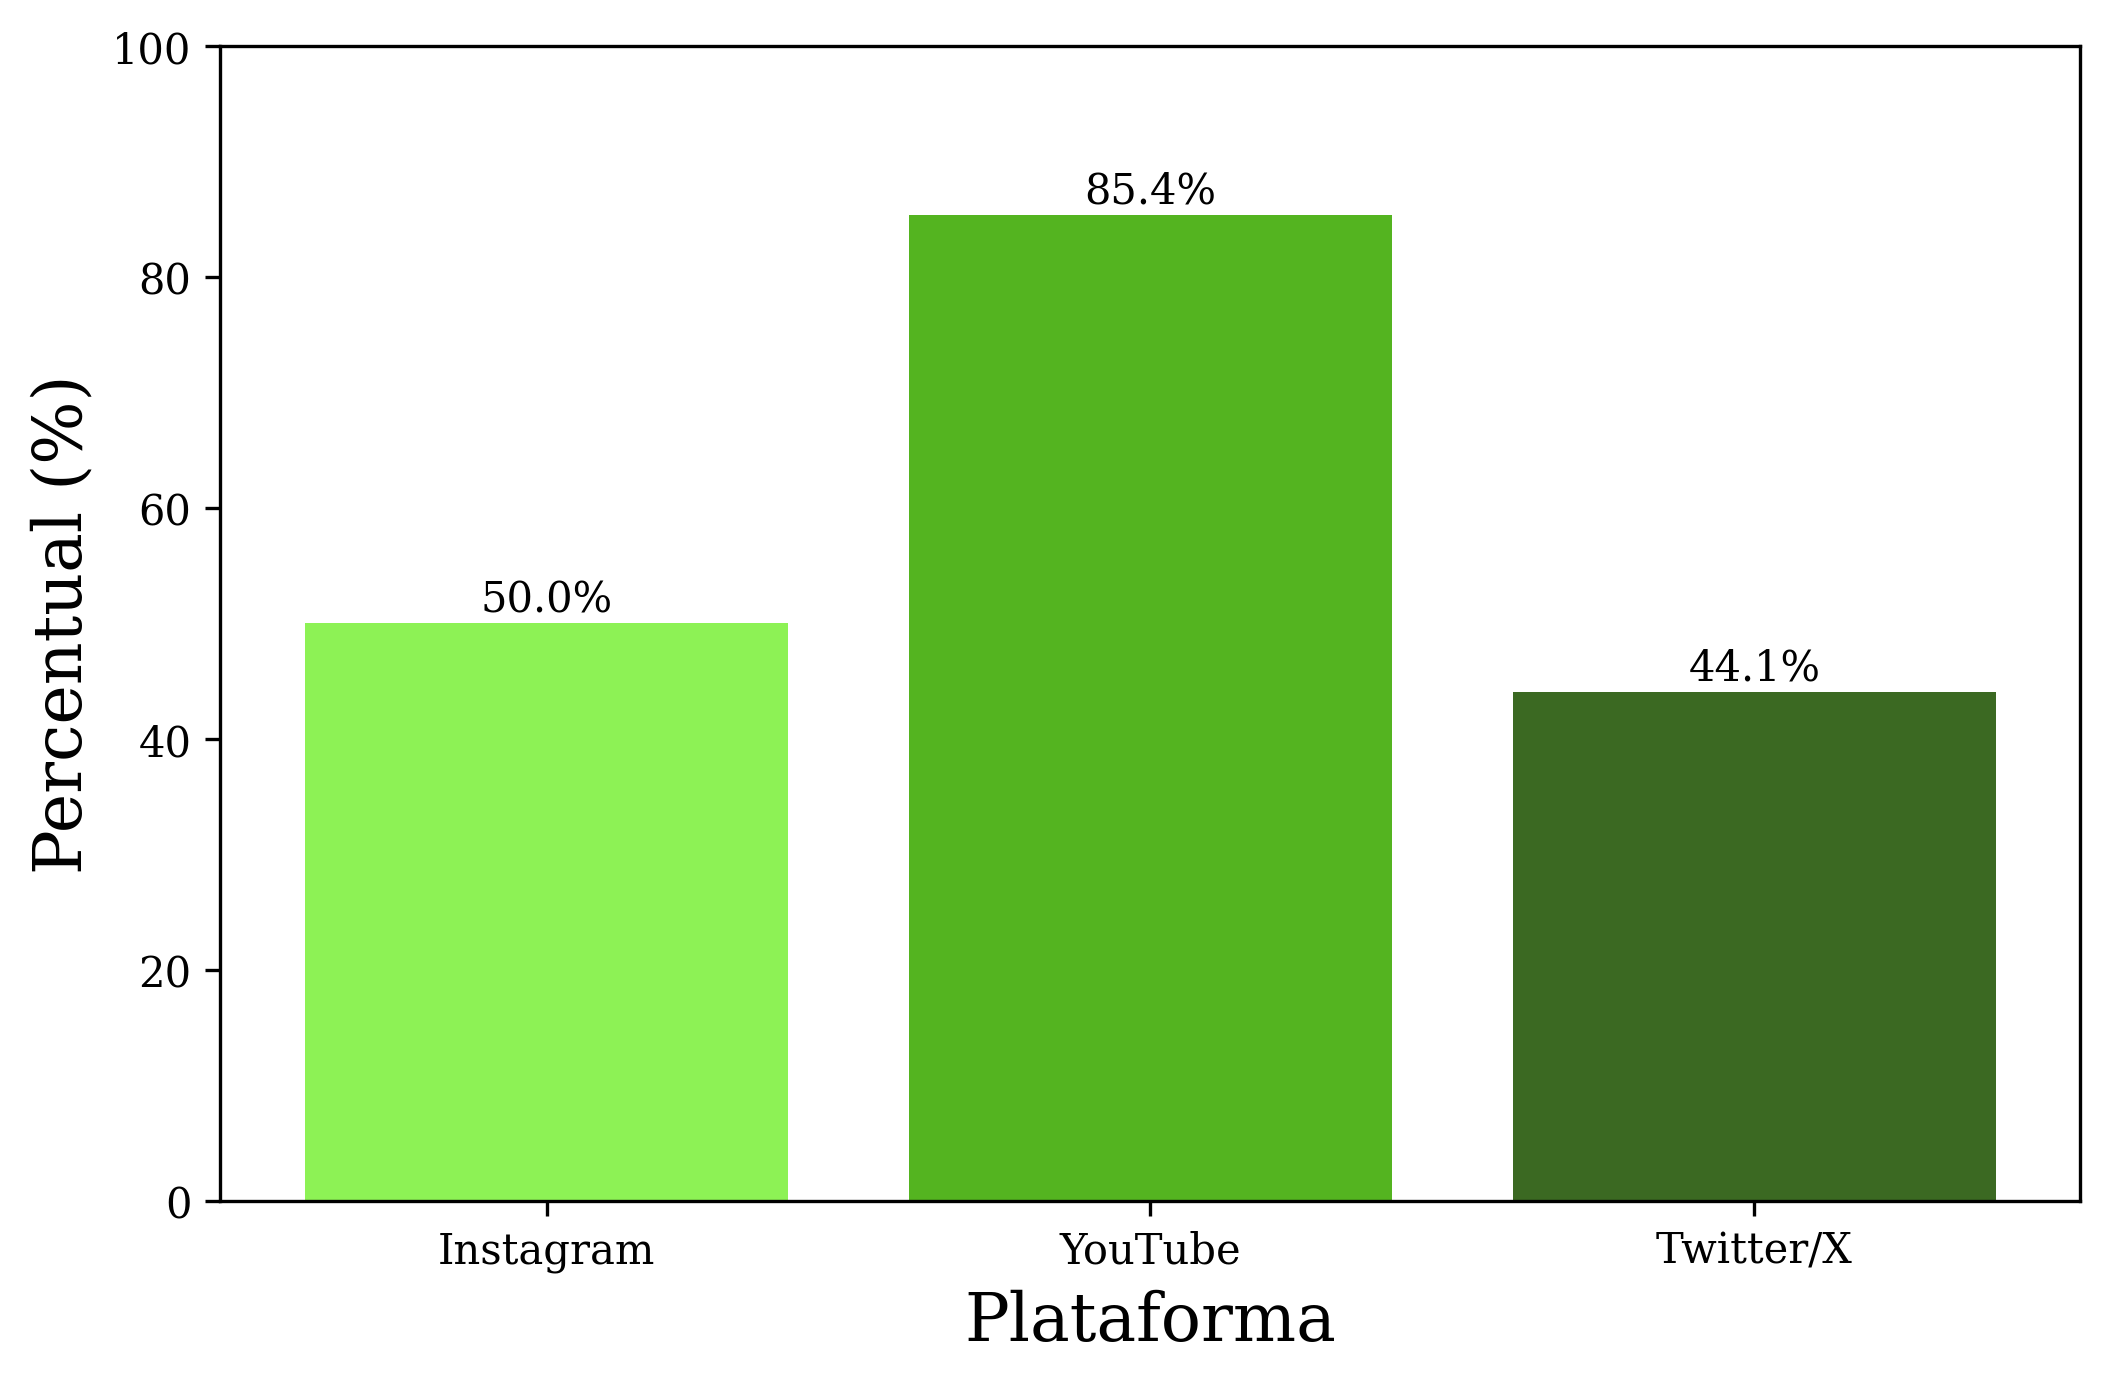

In [29]:
import matplotlib.pyplot as plt

# Cores por plataforma
cores = ["#8DF255", "#54B420", "#3B6922"] 
# Instagram = 8DF255
# YouTube = 54B420
# Twitter/X = 3B6922

# Calculando porcentagem
percentual_odio = (
    resumo_geral["Mensagens de ódio"] /
    resumo_geral["Total de mensagens"]
) * 100

plt.figure(figsize=(8,5), dpi=300)

plt.bar(resumo_geral["Plataforma"],
        percentual_odio,
        color=cores)

plt.xlabel("Plataforma", fontsize=16)
plt.ylabel("Percentual de mensagens de ódio(%)", fontsize=16)

plt.ylim(0,100)  # importante para padronizar escala

for i, v in enumerate(percentual_odio):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.show()

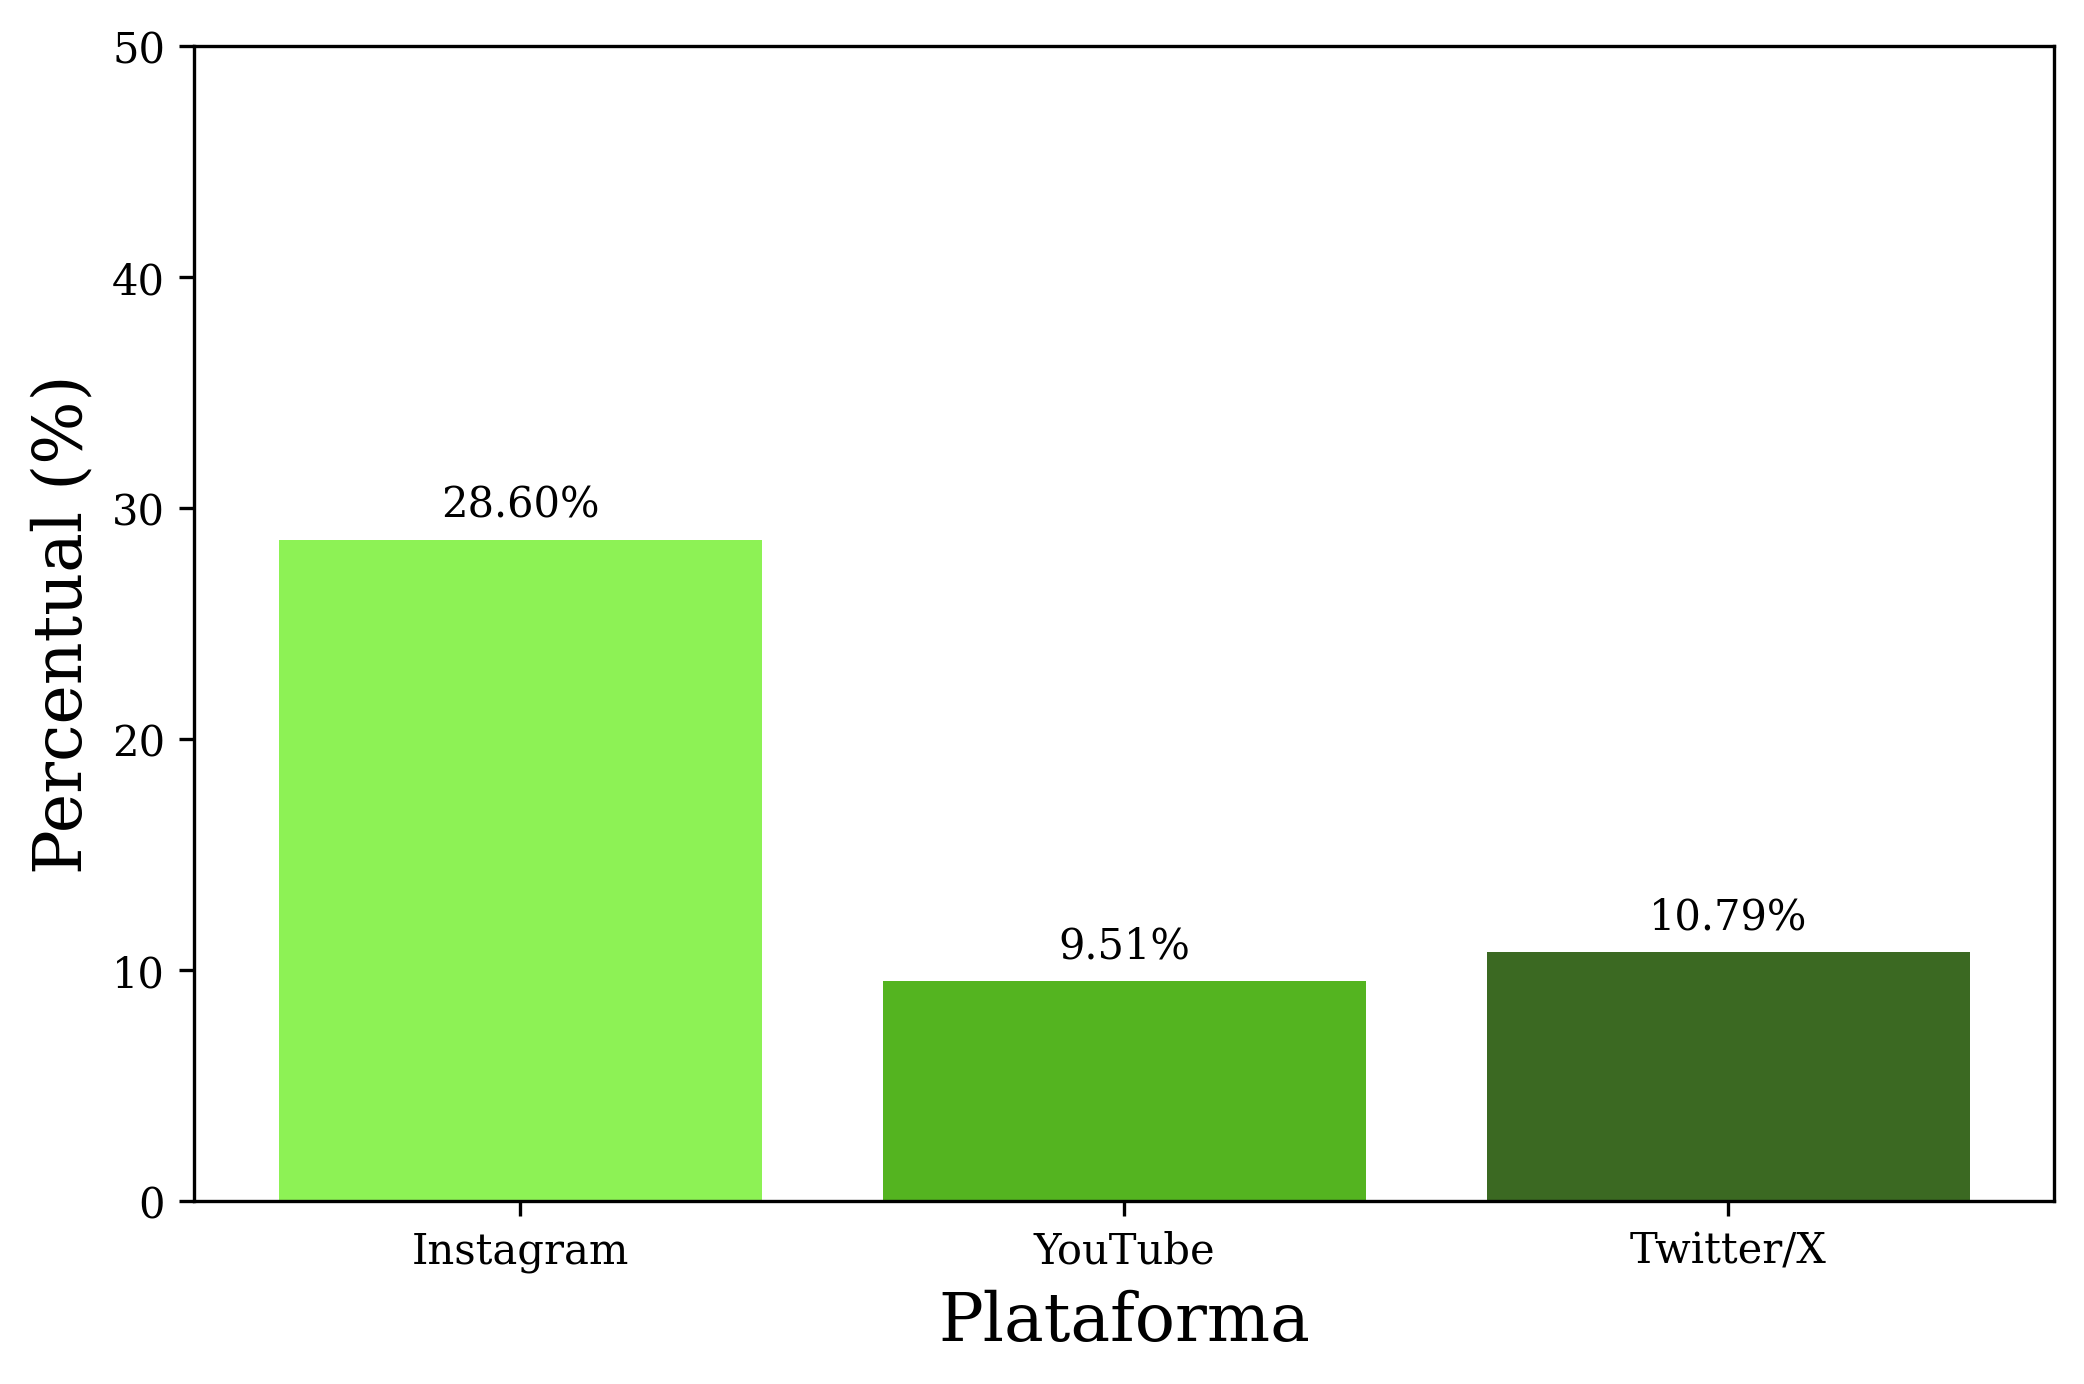

In [31]:
import matplotlib.pyplot as plt

cores = ["#8DF255", "#54B420", "#3B6922"]   

plt.figure(figsize=(8,5), dpi=300)

barras = plt.bar(
    resumo_geral["Plataforma"],
    resumo_geral["% mensagens com emoji"],
    color=cores,
)

plt.xlabel("Plataforma", fontsize=16)
plt.ylabel("Percentual (%)", fontsize=16)

plt.ylim(0, 50)  # padroniza escala

# Adicionando os valores no topo das barras
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura + 1,
        f"{altura:.2f}%",
        ha='center'
    )

plt.show()

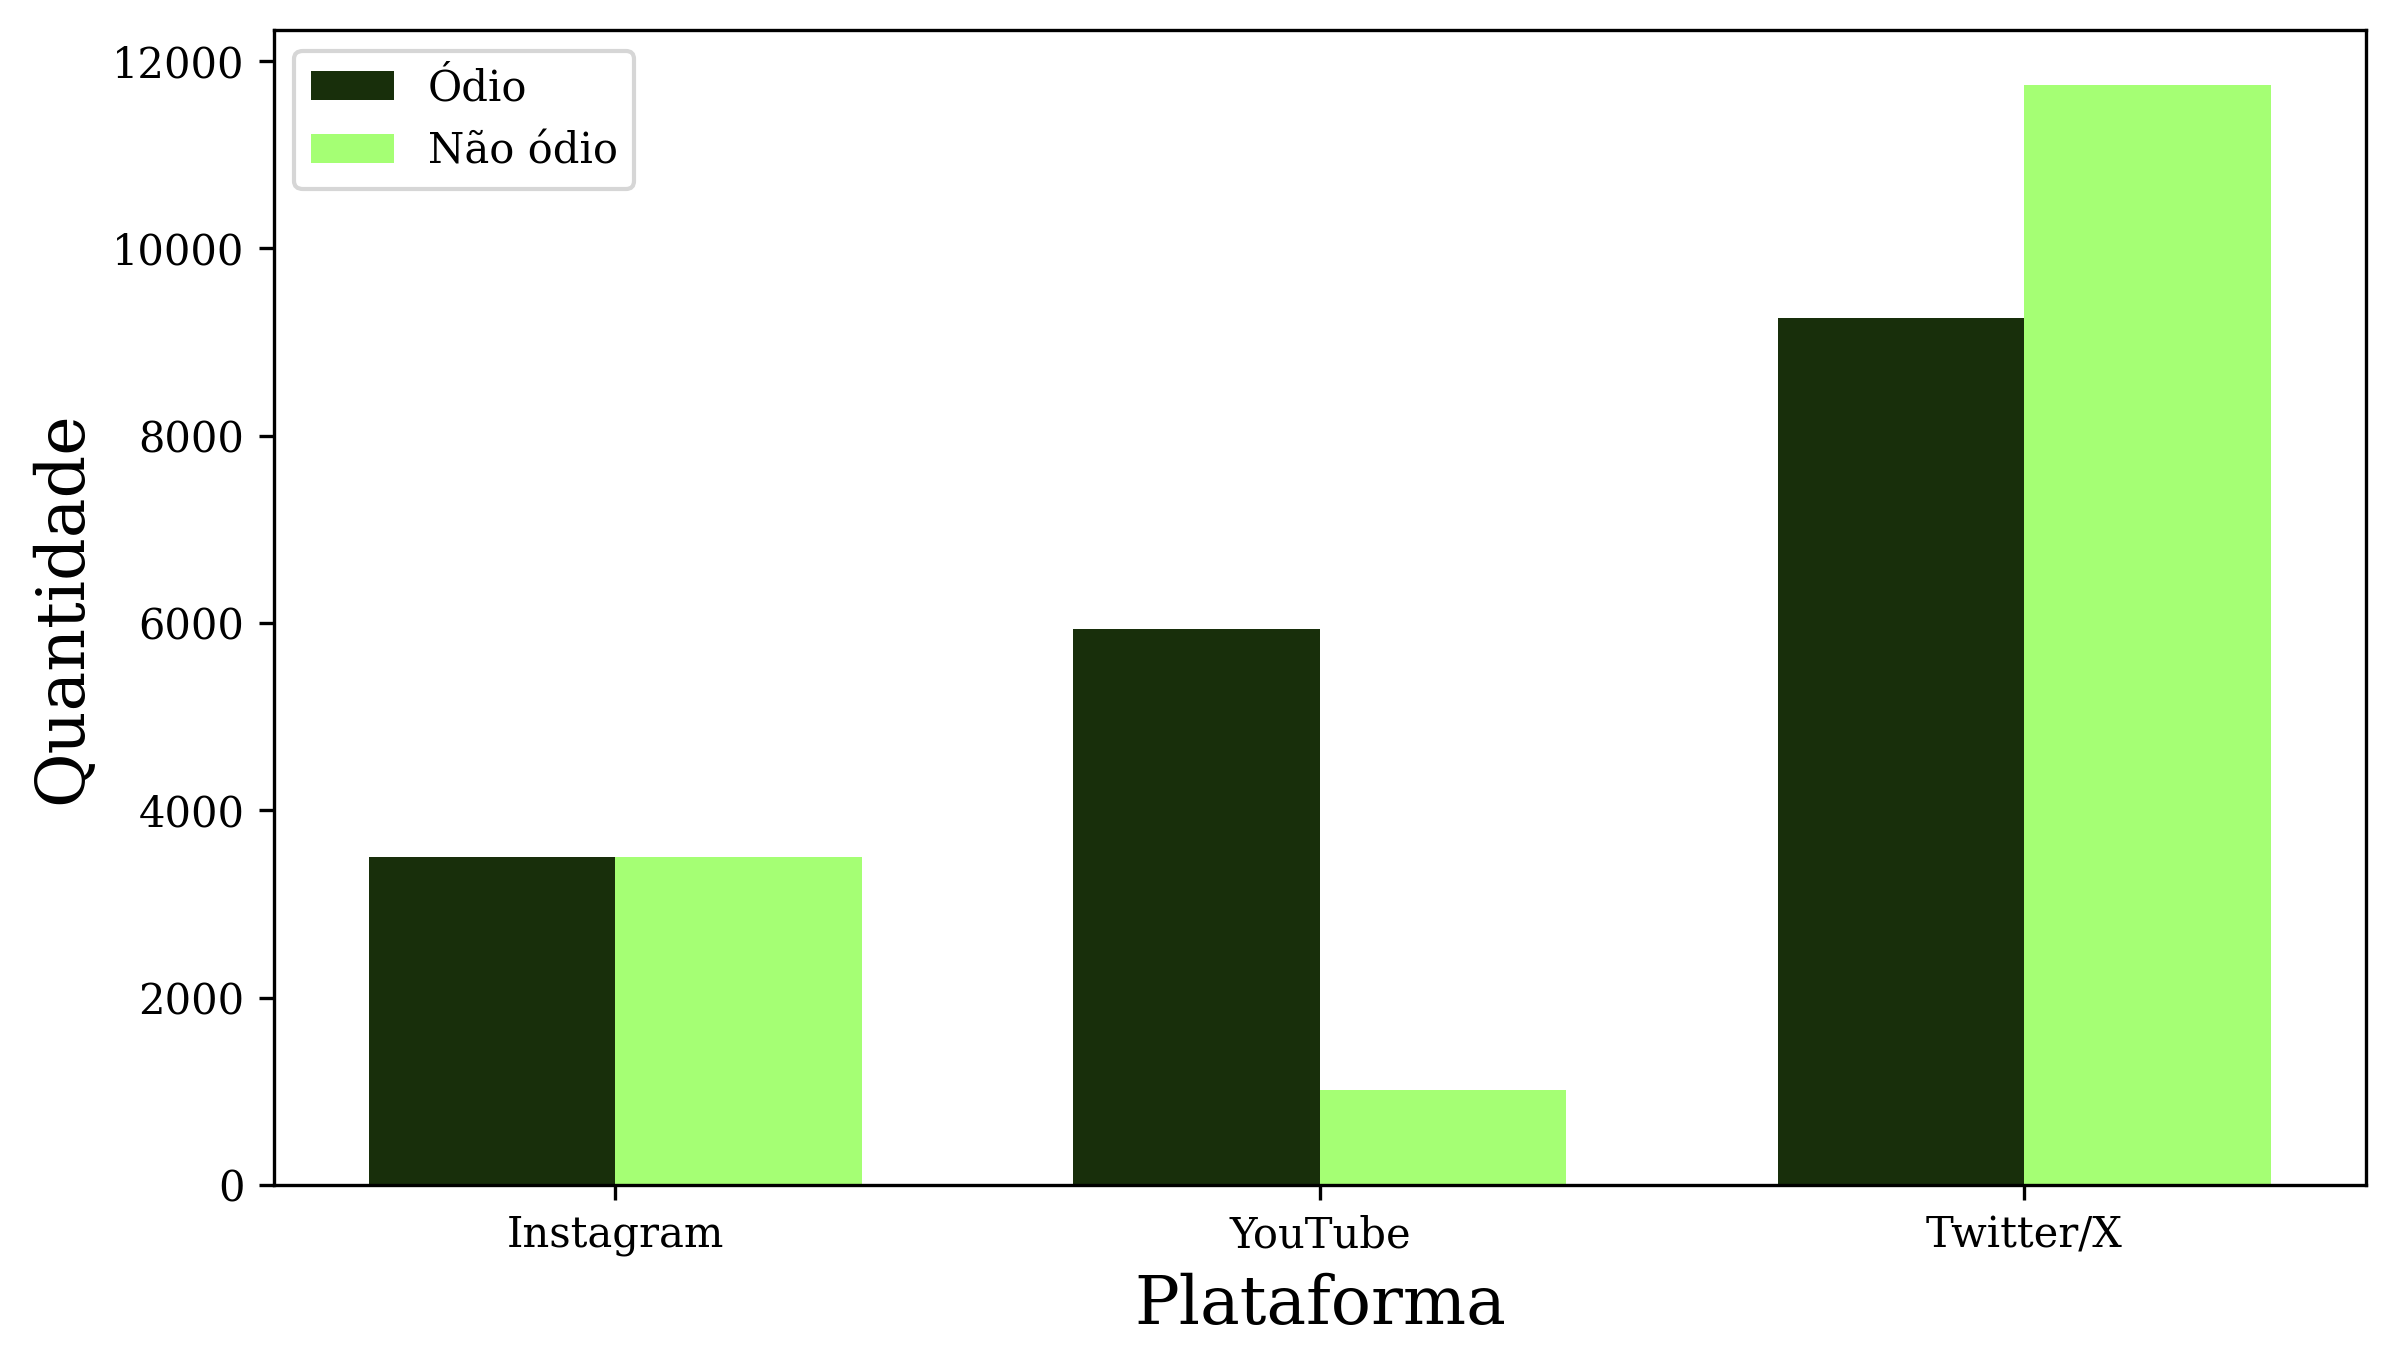

In [32]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(resumo_geral["Plataforma"]))
largura = 0.35

plt.figure(figsize=(9,5), dpi=300)

plt.bar(x - largura/2,
        resumo_geral["Mensagens de ódio"],
        largura,
        label="Ódio",
        color="#182f0b")   # vermelho escuro (firebrick)

plt.bar(x + largura/2,
        resumo_geral["Mensagens não ódio"],
        largura,
        label="Não ódio",
        color="#a5ff74")   # verde escuro (sea green)

plt.xticks(x, resumo_geral["Plataforma"])
plt.xlabel("Plataforma", fontsize=16)
plt.ylabel("Quantidade", fontsize=16)
plt.legend()

plt.show()

In [39]:
import pandas as pd

def gerar_top10(caminho_csv, nome_plataforma):
    df = pd.read_csv(caminho_csv)

    # Evitar divisão por zero
    df["razao_odio"] = df["freq_odio_norm"] / (df["freq_nao_odio_norm"] + 1e-6)

    # (Opcional) remover emojis muito raros
    df = df[df["freq_total"] > 10]

    # Filtrar só os mais associados ao ódio
    df = df[df["razao_odio"] > 1]

    # Ordenar
    df = df.sort_values(by=["razao_odio", "freq_odio"], ascending=[False, False])

    # Top 10
    top10 = df.head(10).copy()

    print(f"\n=== Top 10 - {nome_plataforma} ===")
    print(top10[["emoji", "razao_odio"]])

    return top10


# Gerar para cada plataforma
top10_instagram = gerar_top10("instagram_emojis_normalizado.csv", "Instagram")
top10_youtube = gerar_top10("youtube_emojis_olid-br_normalizado.csv", "YouTube")


=== Top 10 - Instagram ===
    emoji   razao_odio
241     😈  3142.857143
34      💩    50.822123
174     🤮    13.825269
37      😡     6.995919
158     🤬     6.488645
11      😠     4.596782
43      ♂     4.328284
249     👎     4.328284
222     😒     3.995339
187     🤣     3.498775

=== Top 10 - YouTube ===
    emoji   razao_odio
151     🤮  5222.371968
187     💩  2190.026954
0       🤬     3.248721
105     🤢     2.735765
209     🙄     2.393794
25      🏽     2.051824
180     😠     1.709853
220     😡     1.311775
213     🤣     1.091000
181     😭     1.083640


':loudly_crying_face:'

In [40]:
import pandas as pd

def limpar_coluna(col):
    return col.astype(str).str.replace(".", "", regex=False).astype(float)

def top10_twitter(caminho_csv):
    df = pd.read_csv(caminho_csv)

    # Limpar colunas normalizadas
    df["freq_odio_norm"] = limpar_coluna(df["freq_odio_norm"])
    df["freq_nao_odio_norm"] = limpar_coluna(df["freq_nao_odio_norm"])

    df = df[df["freq_nao_odio"] >= 3]

    # Calcular razão
    df["razao_odio"] = df["freq_odio_norm"] / (df["freq_nao_odio_norm"] + 1e-6)

    # ⚠️ Filtro mais leve (evita DataFrame vazio)
    df = df[df["freq_total"] >= 10]

    df = df[df["razao_odio"] > 1]
    
    # Ordenar por associação ao ódio
    df = df.sort_values(by=["razao_odio", "freq_odio"], ascending=[False, False])

    # Top 10 (SEM exigir razao > 1)
    top10 = df.head(10)

    print("\n=== Top 10 - Twitter/X ===")
    print(top10[["emoji", "razao_odio"]])

    return top10


top10_twitter = top10_twitter("twitter_emojis_ToLD-BR_normalizado.csv")


=== Top 10 - Twitter/X ===
    emoji  razao_odio
336     🤤    3.781687
142     😅    1.890844
26      💚    1.684033
230     💜    1.403360


':green_heart:'

In [41]:
import pandas as pd

def limpar_coluna(col):
    return col.astype(str).str.replace(".", "", regex=False).astype(float)

def gerar_top10_norm(caminho_csv, nome_plataforma):
    df = pd.read_csv(caminho_csv)

    # Corrigir colunas (caso venha com separador errado)
    df["freq_odio_norm"] = limpar_coluna(df["freq_odio_norm"])
    df["freq_nao_odio_norm"] = limpar_coluna(df["freq_nao_odio_norm"])

    # Calcular razão
    df["razao_odio"] = df["freq_odio_norm"] / (df["freq_nao_odio_norm"] + 1e-6)

    # Filtro leve (evita ruído)
    df = df[df["freq_total"] >= 10]

    # Ordenar
    df = df.sort_values(by=["razao_odio", "freq_odio_norm"], ascending=[False, False])

    # Top 10
    top10 = df.head(10).copy()
    top10["plataforma"] = nome_plataforma

    # Selecionar colunas finais (normalizadas)
    return top10[["plataforma", "emoji", "razao_odio", "freq_odio_norm", "freq_nao_odio_norm"]]


# Aplicar
insta = gerar_top10_norm("instagram_emojis_normalizado.csv", "Instagram")
twitter = gerar_top10_norm("twitter_emojis_ToLD-BR_normalizado.csv", "Twitter/X")
youtube = gerar_top10_norm("youtube_emojis_olid-br_normalizado.csv", "YouTube")

In [45]:
import pandas as pd

def carregar_dados(caminho_csv, nome_plataforma):
    df = pd.read_csv(caminho_csv)

    # Razão ódio / não ódio
    df["razao_odio"] = df["freq_odio_norm"] / (df["freq_nao_odio_norm"] + 1e-6)

    # Remover emojis muito raros (mesma regra que você já usa)
    df = df[df["freq_total"] > 10]

    # Adicionar nome da plataforma
    df["plataforma"] = nome_plataforma

    return df[["emoji", "razao_odio", "plataforma"]]


# Carregar dados
df_instagram = carregar_dados("instagram_emojis_normalizado.csv", "Instagram")
df_youtube = carregar_dados("youtube_emojis_olid-br_normalizado.csv", "YouTube")
df_twitter = carregar_dados("twitter_emojis_ToLD-BR_normalizado.csv", "Twitter/X")

# Juntar tudo
df_all = pd.concat([df_instagram, df_youtube, df_twitter])

# Classificar comportamento
df_all["tipo"] = df_all["razao_odio"].apply(
    lambda x: "odio" if x > 1 else "nao_odio"
)

# Contar em quantas plataformas cada emoji aparece como ódio/não ódio
resultado = (
    df_all
    .groupby(["emoji", "tipo"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Renomear colunas
resultado = resultado.rename(columns={
    "odio": "qtd_plataformas_odio",
    "nao_odio": "qtd_plataformas_nao_odio"
})

# Ordenar (mais consistentes primeiro)
resultado = resultado.sort_values(
    by=["qtd_plataformas_nao_odio"],
    ascending=False
)

# Mostrar resultado
print("\n=== Consistência entre plataformas ===")
print(resultado.head(10))


=== Consistência entre plataformas ===
tipo emoji  qtd_plataformas_nao_odio  qtd_plataformas_odio
6        ❤                         3                     0
41       😍                         3                     0
22       👏                         3                     0
19       👍                         3                     0
60       🙏                         3                     0
14       🏼                         2                     0
25       💖                         2                     0
24       💕                         2                     0
16       🏾                         2                     0
0        ♀                         2                     0


In [46]:
import emoji
emoji.demojize("👍")

':thumbs_up:'

In [15]:
sempre_odio = resultado[resultado["qtd_plataformas_odio"] == 3]
print("\nSempre associados a ódio:")
print(sempre_odio)


Sempre associados a ódio:
Empty DataFrame
Columns: [emoji, qtd_plataformas_nao_odio, qtd_plataformas_odio]
Index: []


In [17]:
sempre_nao_odio = resultado[resultado["qtd_plataformas_nao_odio"] == 3]
print("\nSempre associados a não ódio:")
print(sempre_nao_odio)


Sempre associados a não ódio:
tipo emoji  qtd_plataformas_nao_odio  qtd_plataformas_odio
6        ❤                         3                     0
19       👍                         3                     0
22       👏                         3                     0
41       😍                         3                     0
60       🙏                         3                     0


In [16]:
# 🔧 Função para limpar colunas (caso Twitter venha com problema de formatação)
def limpar_coluna(col):
    return col.astype(str).str.replace(".", "", regex=False).astype(float)


# 🔴 Twitter (tratamento especial)
def gerar_top10_twitter(caminho_csv):
    df = pd.read_csv(caminho_csv)

    # Limpar colunas
    df["freq_odio_norm"] = limpar_coluna(df["freq_odio_norm"])
    df["freq_nao_odio_norm"] = limpar_coluna(df["freq_nao_odio_norm"])

    # Filtros
    df = df[df["freq_nao_odio"] >= 3]
    df["razao_odio"] = df["freq_odio_norm"] / (df["freq_nao_odio_norm"] + 1e-6)
    df = df[df["freq_total"] >= 10]
    df = df[df["razao_odio"] > 1]

    # Ordenar
    df = df.sort_values(by=["razao_odio", "freq_odio"], ascending=[False, False])

    # Top 10
    top10 = df.head(10)

    print("\n=== Top 10 - Twitter/X ===")
    print(top10[["emoji", "razao_odio"]])

    return set(top10["emoji"])


# 🟣 Instagram / 🔴 YouTube (padrão)
def gerar_top10(caminho_csv, nome):
    df = pd.read_csv(caminho_csv)

    df["razao_odio"] = df["freq_odio_norm"] / (df["freq_nao_odio_norm"] + 1e-6)
    df = df[df["freq_total"] > 10]
    df = df[df["razao_odio"] > 1]

    df = df.sort_values(by=["razao_odio", "freq_odio"], ascending=[False, False])

    top10 = df.head(10)

    print(f"\n=== Top 10 - {nome} ===")
    print(top10[["emoji", "razao_odio"]])

    return set(top10["emoji"])

# 📊 Gerar conjuntos
instagram = gerar_top10("instagram_emojis_normalizado.csv", "Instagram")
youtube = gerar_top10("youtube_emojis_olid-br_normalizado.csv", "YouTube")
twitter = gerar_top10_twitter("twitter_emojis_ToLD-BR_normalizado.csv")


# 🔥 Interseções

# Todos os três
intersecao_3 = instagram & youtube & twitter

# Duplas (sem o terceiro)
yt_insta = (youtube & instagram) - twitter
yt_twitter = (youtube & twitter) - instagram
insta_twitter = (instagram & twitter) - youtube

# Exclusivos
apenas_youtube = youtube - instagram - twitter
apenas_instagram = instagram - youtube - twitter
apenas_twitter = twitter - youtube - instagram


# 📊 Função para exibir
def mostrar(nome, conjunto):
    print(f"\n=== {nome} ({len(conjunto)}) ===")
    print(", ".join(conjunto) if conjunto else "Nenhum")


# 📢 Mostrar resultados
mostrar("Interseção dos 3", intersecao_3)
mostrar("YouTube ∩ Instagram", yt_insta)
mostrar("YouTube ∩ Twitter/X", yt_twitter)
mostrar("Instagram ∩ Twitter/X", insta_twitter)
mostrar("Apenas YouTube", apenas_youtube)
mostrar("Apenas Instagram", apenas_instagram)
mostrar("Apenas Twitter/X", apenas_twitter)


=== Top 10 - Instagram ===
    emoji   razao_odio
241     😈  3142.857143
34      💩    50.822123
174     🤮    13.825269
37      😡     6.995919
158     🤬     6.488645
11      😠     4.596782
43      ♂     4.328284
249     👎     4.328284
222     😒     3.995339
187     🤣     3.498775

=== Top 10 - YouTube ===
    emoji   razao_odio
151     🤮  5222.371968
187     💩  2190.026954
0       🤬     3.248721
105     🤢     2.735765
209     🙄     2.393794
25      🏽     2.051824
180     😠     1.709853
220     😡     1.311775
213     🤣     1.091000
181     😭     1.083640

=== Top 10 - Twitter/X ===
    emoji  razao_odio
336     🤤    3.781687
142     😅    1.890844
26      💚    1.684033
230     💜    1.403360

=== Interseção dos 3 (0) ===
Nenhum

=== YouTube ∩ Instagram (6) ===
💩, 🤣, 😡, 🤬, 🤮, 😠

=== YouTube ∩ Twitter/X (0) ===
Nenhum

=== Instagram ∩ Twitter/X (0) ===
Nenhum

=== Apenas YouTube (4) ===
🙄, 🤢, 🏽, 😭

=== Apenas Instagram (4) ===
😈, ♂, 😒, 👎

=== Apenas Twitter/X (4) ===
🤤, 💜, 💚, 😅
